# Model Training and Comparative Evaluation

### AAI-590 Capstone Project - University of San Diego
### Team Members:
 - Jamshed Nabizada
 - Swapnil Patil

## Purpose

This notebook trains and evaluates four candidate classifiers for multiclass NOVA food processing group prediction. The goal is to identify the most suitable model for further hyperparameter optimization by comparing validation performance under consistent evaluation conditions.

All models are trained on the same preprocessed features produced by the Feature Engineering notebook and evaluated using a shared metrics pipeline. Class imbalance is handled explicitly through sample/class weighting. The test set is reserved for final evaluation and is not used for model selection.

**Models evaluated:**
1. Random Forest
2. XGBoost
3. MLP Neural Network
4. LightGBM

## Environment Setup and Configuration

In [45]:
%pip install -q -r requirements.txt lightgbm

Note: you may need to restart the kernel to use updated packages.


In [46]:
# suppress warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

# force-reload src.modeling modules so code changes are always picked up
%load_ext autoreload
%autoreload 2

import json
import gc
import time
from pathlib import Path
from typing import Any, Dict, List, Optional
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from IPython.display import display
from src.modeling import (
    ARTIFACTS_DIR,
    N_CLASSES,
    NOVA_LABELS,
    PRIMARY_METRIC,
    RANDOM_STATE,
    RESULTS_DIR,
    MetricsEvaluator,
    ModelPlotter,
    ModelResult,
    ModelRunner,
)

np.random.seed(RANDOM_STATE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Prepared Data

Load the train/validation/test splits, feature names, class weights, and scaler produced by the Feature Engineering notebook. A stratified train-validation-test split was used to preserve the class distribution across all NOVA groups, with the training set used for model fitting, the validation set for model comparison and selection, and the test set reserved for final unbiased evaluation.

In [47]:
# load saved splits and metadata from Feature Engineering notebook (Notebook 02)
splits = joblib.load(ARTIFACTS_DIR / "data_splits.joblib")

# unpack train/validation/test splits (unscaled and scaled)
X_train = splits["X_train"]
X_val = splits["X_val"]
X_test = splits["X_test"]
y_train = splits["y_train"]
y_val = splits["y_val"]
y_test = splits["y_test"]

# scaled versions needed for the MLP neural network
X_train_scaled = splits["X_train_scaled"]
X_val_scaled = splits["X_val_scaled"]
X_test_scaled = splits["X_test_scaled"]

# feature names and class weights computed during feature engineering
feature_names = splits["feature_names"]
class_weights_dict = splits["class_weights"]

# load the fitted StandardScaler for potential downstream use
scaler = joblib.load(ARTIFACTS_DIR / "standard_scaler.joblib")

print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Class weights: {class_weights_dict}")

Features (20): ['energy_100g', 'fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'saturated_fat_100g', 'additives_n', 'trans_fat_100g', 'added_sugars_100g', 'monounsaturated_fat_100g', 'polyunsaturated_fat_100g', 'starch_100g', 'nutriscore_score', 'sugar_fiber_ratio', 'fat_protein_ratio', 'additives_per_energy', 'trans_fat_ratio', 'unsaturated_fat_ratio']
Train: (134343, 20)  Val: (44781, 20)  Test: (44782, 20)
Class weights: {0: 2.082304144036902, 1: 6.811450474568021, 2: 1.2451119959072001, 3: 0.3891337444125437}


In [48]:
# verify that class distributions are consistent across all three splits
# stratified splitting should produce similar NOVA group proportions
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = y.value_counts().sort_index()
    pcts = (counts / len(y) * 100).round(1)
    dist = ", ".join(f"NOVA {i+1}: {c:,} ({pcts[i]}%)" for i, c in counts.items())
    print(f"{name:5s} ({len(y):,}) -- {dist}")

Train (134,343) -- NOVA 1: 16,129 (12.0%), NOVA 2: 4,931 (3.7%), NOVA 3: 26,974 (20.1%), NOVA 4: 86,309 (64.2%)
Val   (44,781) -- NOVA 1: 5,376 (12.0%), NOVA 2: 1,644 (3.7%), NOVA 3: 8,991 (20.1%), NOVA 4: 28,770 (64.2%)
Test  (44,782) -- NOVA 1: 5,377 (12.0%), NOVA 2: 1,643 (3.7%), NOVA 3: 8,992 (20.1%), NOVA 4: 28,770 (64.2%)


## Class Imbalance Strategy

The NOVA target is heavily imbalanced toward NOVA 4. All models use class weight based handling to give higher importance to underrepresented classes during training. No resampling is applied to avoid data leakage and excessive memory usage.

In [49]:
# compute sklearn-style balanced class weights (inverse frequency)
# this gives higher weight to underrepresented classes (e.g., NOVA 2)
classes = np.array(sorted(y_train.unique()))
sklearn_class_weights = compute_class_weight("balanced", classes=classes, y=y_train)
sklearn_cw_dict = dict(zip(classes, sklearn_class_weights))

# per-sample weights for train set (used by XGBoost and LightGBM via sample_weight)
train_sample_weights = compute_sample_weight("balanced", y_train)

print("Balanced class weights (sklearn):")
for cls, w in sklearn_cw_dict.items():
    print(f"  NOVA {cls + 1}: {w:.4f}")

Balanced class weights (sklearn):
  NOVA 1: 2.0823
  NOVA 2: 6.8111
  NOVA 3: 1.2451
  NOVA 4: 0.3891


## Model Pipeline

Reusable classes for metrics computation, model execution, and plotting to ensure consistent evaluation across all models.

In [50]:
# instantiate shared evaluation objects used by all four models
# MetricsEvaluator: computes accuracy, F1, precision, recall, log loss, ROC-AUC, etc.
# ModelRunner: wraps fit/predict with timing and calls MetricsEvaluator
# ModelPlotter: generates confusion matrices, bar charts, heatmaps, etc.
evaluator = MetricsEvaluator(labels=NOVA_LABELS, n_classes=N_CLASSES)
runner = ModelRunner(evaluator=evaluator)
plotter = ModelPlotter()

# dictionary to collect ModelResult objects from each trained model
all_results: Dict[str, ModelResult] = {}

---
## Random Forest Model

Random Forest is used because it is a strong and reliable baseline for structured tabular data like nutritional and additive features. It can capture nonlinear relationships, is robust to noise and overfitting, and provides feature importance, making it useful both for performance comparison and interpretability in multiclass food processing classification.

In [51]:
# Random Forest: tree-based, uses unscaled data (invariant to feature scaling)
# class_weight="balanced" handles the NOVA 4 dominance directly in the loss function
rf_model = RandomForestClassifier(
    n_estimators=400,         # number of trees in the ensemble
    max_depth=25,             # limit tree depth to control overfitting
    min_samples_split=5,      # minimum samples to split an internal node
    min_samples_leaf=2,       # minimum samples at a leaf node
    max_features="sqrt",      # random subset of features per split for diversity
    class_weight="balanced",  # auto-adjust weights inversely proportional to class frequency
    n_jobs=-1,                # use all CPU cores for parallel training
    random_state=RANDOM_STATE,
)

# train and evaluate using the shared ModelRunner pipeline
rf_result = runner.run(
    name="Random Forest",
    model=rf_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
)
all_results[rf_result.name] = rf_result

print(f"\nRandom Forest -- Macro F1: {rf_result.metrics['Macro F1']:.4f}  "
      f"Balanced Acc: {rf_result.metrics['Balanced Accuracy']:.4f}  "
      f"Train: {rf_result.metrics['Train Time (s)']:.1f}s")
display(rf_result.per_class)


Random Forest -- Macro F1: 0.8482  Balanced Acc: 0.8755  Train: 14.9s


,Class,Precision,Recall,F1,Support
0,NOVA 1,0.799643,0.917597,0.854569,5376.0
1,NOVA 2,0.824104,0.923358,0.870912,1644.0
2,NOVA 3,0.735291,0.765877,0.750272,8991.0
3,NOVA 4,0.939719,0.895134,0.916885,28770.0


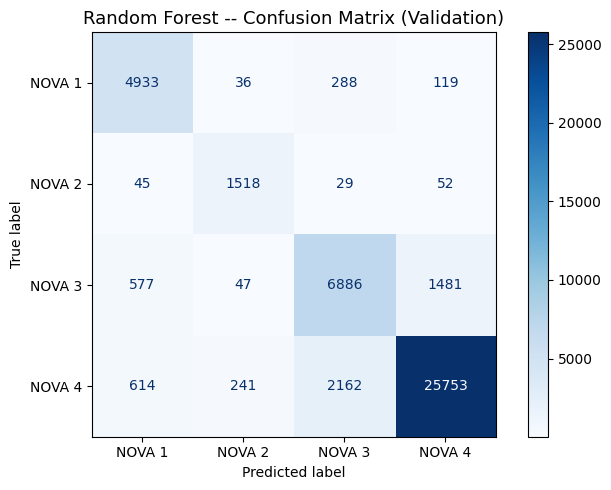

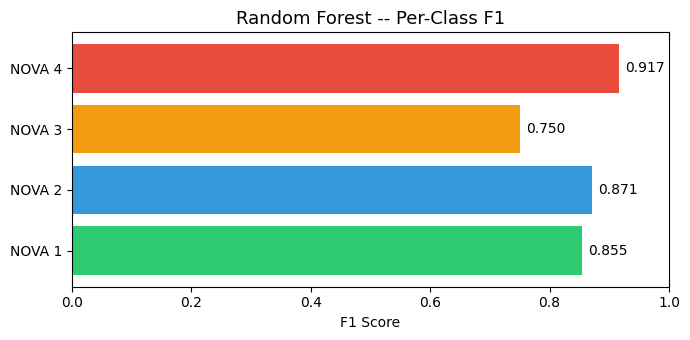

In [52]:
# confusion matrix and per-class F1 bar chart for Random Forest
plotter.plot_confusion_matrix(rf_result.confusion, NOVA_LABELS, "Random Forest -- Confusion Matrix (Validation)")
plotter.plot_per_class_f1(rf_result, NOVA_LABELS)

### Interpretation
- Random Forest delivered strong overall validation performance, with a Macro F1 of 0.8482 and Balanced Accuracy of 0.8755, showing that it handled the multiclass and imbalanced NOVA classification task effectively rather than relying only on majority-class accuracy.
- The model performed best on NOVA 4 (F1 = 0.917) and also showed strong results for NOVA 1 (F1 = 0.855) and NOVA 2 (F1 = 0.871), indicating that nutritional and additive features provide clear signal for these classes.
- NOVA 3 was the most difficult class (F1 = 0.750), with notable confusion against NOVA 4, suggesting overlap in feature patterns between moderately processed and ultra-processed foods, which remains a key challenge for further model improvement.

---
## XGBoost Model

Gradient-boosted tree classifier with sample-weight-based imbalance handling. XGBoost is used because it is one of the most effective algorithms for imbalanced tabular classification, as it can capture complex nonlinear relationships among nutritional and additive features while often delivering stronger multiclass predictive performance than standard tree-based methods.

In [53]:
# XGBoost: gradient-boosted trees, uses unscaled data (tree-based, scale-invariant)
# sample_weight handles class imbalance (XGBoost does not support class_weight directly)
xgb_model = XGBClassifier(
    objective="multi:softprob",  # multiclass with probability outputs (needed for log loss)
    num_class=N_CLASSES,
    eval_metric="mlogloss",      # multiclass log loss for early stopping monitoring
    n_estimators=500,            # boosting rounds
    max_depth=8,                 # tree depth — deeper than RF due to sequential learning
    learning_rate=0.1,           # step size shrinkage to prevent overfitting
    subsample=0.8,               # row subsampling per tree for regularization
    colsample_bytree=0.8,        # column subsampling per tree for regularization
    reg_alpha=0.1,               # L1 regularization on leaf weights
    reg_lambda=1.0,              # L2 regularization on leaf weights
    tree_method="hist",          # histogram-based splitting for faster training
    random_state=RANDOM_STATE,
    verbosity=0,                 # suppress XGBoost warnings
)

# train with sample weights and validation set for monitoring
xgb_result = runner.run(
    name="XGBoost",
    model=xgb_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    fit_kwargs={
        "sample_weight": train_sample_weights,
        "eval_set": [(X_val, y_val)],
        "verbose": False,
    },
)
all_results[xgb_result.name] = xgb_result

print(f"\nXGBoost: \n Macro F1: {xgb_result.metrics['Macro F1']:.4f}  "
      f"Balanced Acc: {xgb_result.metrics['Balanced Accuracy']:.4f}  "
      f"Train: {xgb_result.metrics['Train Time (s)']:.1f}s")
display(xgb_result.per_class)


XGBoost: 
 Macro F1: 0.8561  Balanced Acc: 0.8824  Train: 13.1s


,Class,Precision,Recall,F1,Support
0,NOVA 1,0.801262,0.920945,0.856945,5376.0
1,NOVA 2,0.878190,0.920925,0.899050,1644.0
2,NOVA 3,0.706942,0.807585,0.753920,8991.0
3,NOVA 4,0.951592,0.880049,0.914423,28770.0


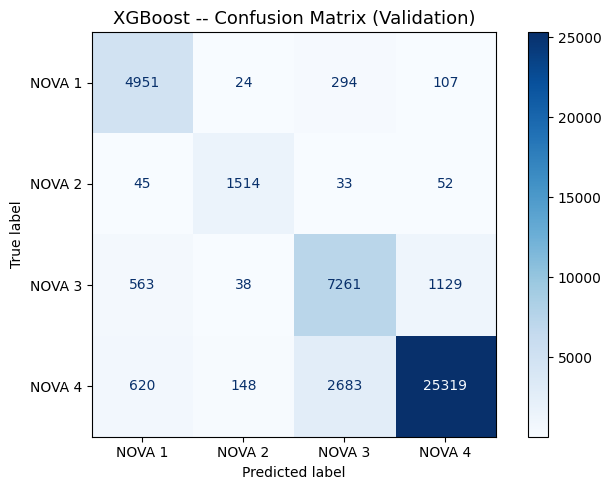

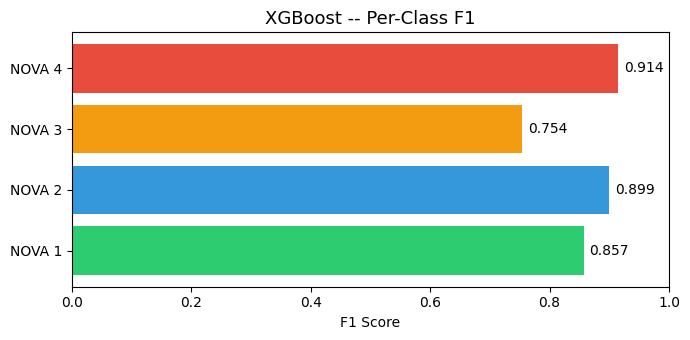

In [54]:
# confusion matrix and per-class F1 bar chart for XGBoost
plotter.plot_confusion_matrix(xgb_result.confusion, NOVA_LABELS, "XGBoost -- Confusion Matrix (Validation)")
plotter.plot_per_class_f1(xgb_result, NOVA_LABELS)

### Interpretation
- XGBoost achieved the best overall class-balanced performance among the evaluated models, with a Macro F1 of 0.8561 and Balanced Accuracy of 0.8824, indicating strong effectiveness for this imbalanced multiclass NOVA classification task.
- The model performed especially well for NOVA 2 (F1 = 0.899) and NOVA 4 (F1 = 0.914), while also maintaining solid results for NOVA 1 (F1 = 0.857), showing that the nutritional and additive features provide strong discriminatory signal for these classes.
- NOVA 3 remained the most challenging class (F1 = 0.754), with confusion still occurring mainly with NOVA 4, but XGBoost improved recall for NOVA 3 compared with the other models, which is one reason it was selected as the strongest candidate for final tuning.

---
## MLP Neural Network Model

Feedforward neural network using scaled features. The sklearn MLPClassifier provides a multi-layer perceptron with backpropagation, early stopping, and adaptive learning rate support suitable for tabular classification.

In [55]:
# MLP: feedforward neural network — requires scaled features (distance-based model)
# three hidden layers with decreasing width to progressively compress representations
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # 3-layer architecture: wide → narrow
    activation="relu",                   # ReLU avoids vanishing gradient problem
    solver="adam",                       # Adam optimizer with adaptive learning rates
    learning_rate="adaptive",            # reduce learning rate when loss plateaus
    learning_rate_init=1e-3,             # initial learning rate
    max_iter=200,                        # maximum training epochs
    early_stopping=True,                 # stop when validation loss stops improving
    validation_fraction=0.15,            # 15% of training data held out for early stopping
    n_iter_no_change=15,                 # patience: epochs without improvement before stopping
    batch_size=512,                      # mini-batch size for stochastic gradient descent
    random_state=RANDOM_STATE,
    verbose=False,
)

# train on SCALED data (MLP is sensitive to feature magnitude)
mlp_result = runner.run(
    name="MLP",
    model=mlp_model,
    X_train=X_train_scaled,
    y_train=y_train,
    X_val=X_val_scaled,
    y_val=y_val,
)
all_results[mlp_result.name] = mlp_result

print(f"\nMLP: \n Macro F1: {mlp_result.metrics['Macro F1']:.4f}  "
      f"Balanced Acc: {mlp_result.metrics['Balanced Accuracy']:.4f}  "
      f"Train: {mlp_result.metrics['Train Time (s)']:.1f}s  "
      f"Iterations: {mlp_model.n_iter_}")
display(mlp_result.per_class)


MLP: 
 Macro F1: 0.8270  Balanced Acc: 0.8321  Train: 87.7s  Iterations: 61


,Class,Precision,Recall,F1,Support
0,NOVA 1,0.809524,0.847470,0.828063,5376.0
1,NOVA 2,0.862522,0.877737,0.870063,1644.0
2,NOVA 3,0.705896,0.697809,0.701829,8991.0
3,NOVA 4,0.910989,0.905353,0.908162,28770.0


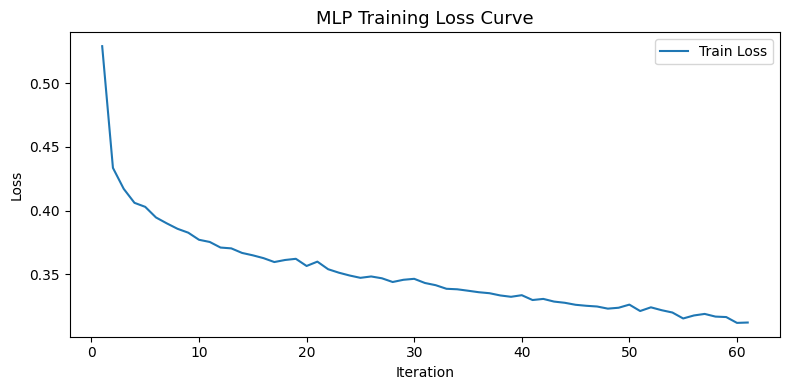

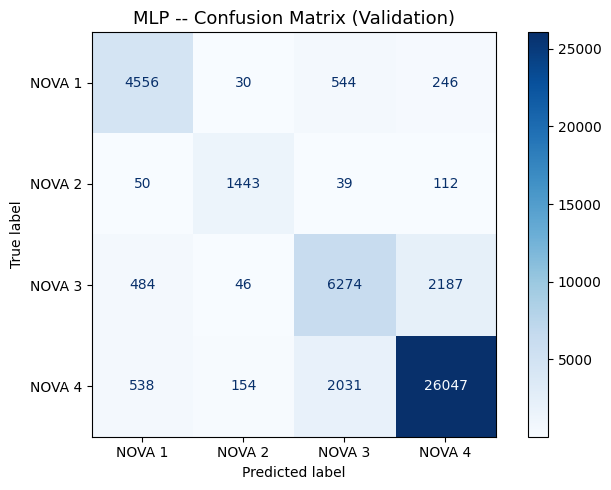

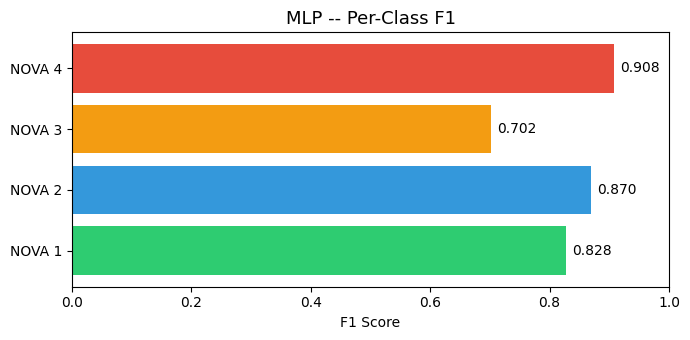

In [56]:
# training loss curve shows convergence behavior and early stopping point
plotter.plot_mlp_loss_curve(mlp_model.loss_curve_)

# confusion matrix and per-class F1 bar chart for MLP
plotter.plot_confusion_matrix(mlp_result.confusion, NOVA_LABELS, "MLP -- Confusion Matrix (Validation)")
plotter.plot_per_class_f1(mlp_result, NOVA_LABELS)

In [57]:
# free memory after MLP training
gc.collect()

60774

### Interpretation
- The MLP produced reasonable overall performance, with a Macro F1 of 0.8270 and Balanced Accuracy of 0.8321, showing that a neural network can learn meaningful patterns from the structured nutrition data, but it did not outperform the tree-based models.
- The model performed best on NOVA 4 (F1 = 0.908) and NOVA 2 (F1 = 0.870), while performance for NOVA 1 (F1 = 0.828) remained acceptable, indicating that the network captured general class structure but with weaker separation than XGBoost and Random Forest.
- NOVA 3 was again the most difficult class (F1 = 0.702), with substantial confusion into NOVA 4, and the longer training time (87.7 seconds) combined with lower validation performance suggests that the MLP was less efficient and less effective than the boosted tree approaches for this tabular classification problem.

---
## LightGBM Model

Gradient-boosted tree classifier optimized for speed. LightGBM uses histogram-based splitting and supports direct class weight handling for multiclass problems.

In [58]:
# LightGBM callbacks for logging and early stopping
from lightgbm import log_evaluation, early_stopping

# LightGBM: histogram-based gradient boosting, uses unscaled data (tree-based)
# class_weight="balanced" handles imbalance natively within the loss function
lgbm_model = LGBMClassifier(
    objective="multiclass",
    num_class=N_CLASSES,
    metric="multi_logloss",       # validation metric for early stopping
    n_estimators=500,             # maximum boosting rounds
    max_depth=10,                 # slightly deeper trees than XGBoost
    learning_rate=0.1,            # step size shrinkage
    num_leaves=63,                # max leaves per tree (LightGBM-specific, leaf-wise growth)
    subsample=0.8,                # row subsampling for regularization
    colsample_bytree=0.8,         # column subsampling for regularization
    reg_alpha=0.1,                # L1 regularization
    reg_lambda=1.0,               # L2 regularization
    class_weight="balanced",      # auto-adjust weights inversely proportional to class frequency
    n_jobs=-1,                    # use all CPU cores
    random_state=RANDOM_STATE,
    verbose=-1,                   # suppress LightGBM training output
)

# train with early stopping on validation multiclass log loss
lgbm_result = runner.run(
    name="LightGBM",
    model=lgbm_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    fit_kwargs={
        "eval_set": [(X_val, y_val)],
        "callbacks": [log_evaluation(period=-1), early_stopping(stopping_rounds=50)],
    },
)
all_results[lgbm_result.name] = lgbm_result

print(f"\nLightGBM: \n Macro F1: {lgbm_result.metrics['Macro F1']:.4f}  "
      f"Balanced Acc: {lgbm_result.metrics['Balanced Accuracy']:.4f}  "
      f"Train: {lgbm_result.metrics['Train Time (s)']:.1f}s")
display(lgbm_result.per_class)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.336266

LightGBM: 
 Macro F1: 0.8461  Balanced Acc: 0.8806  Train: 17.4s


,Class,Precision,Recall,F1,Support
0,NOVA 1,0.795801,0.923549,0.854929,5376.0
1,NOVA 2,0.830685,0.922141,0.874027,1644.0
2,NOVA 3,0.693852,0.807140,0.746221,8991.0
3,NOVA 4,0.952776,0.869586,0.909283,28770.0


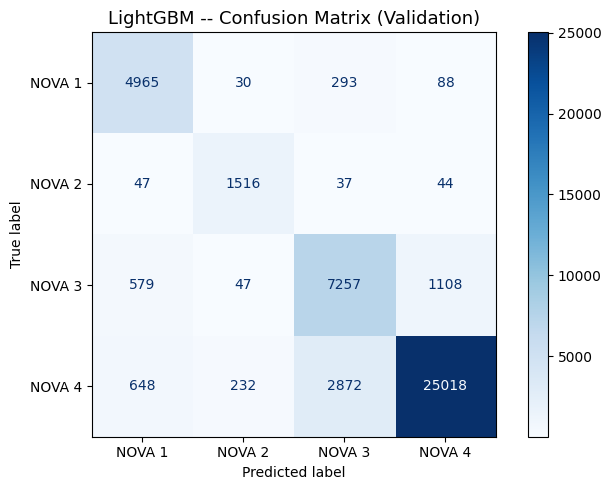

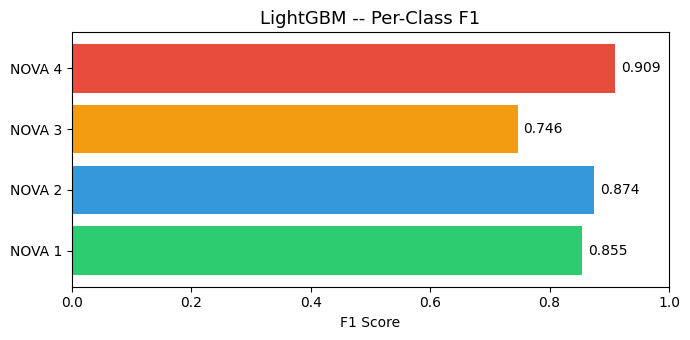

In [59]:
# confusion matrix and per-class F1 bar chart for LightGBM
plotter.plot_confusion_matrix(lgbm_result.confusion, NOVA_LABELS, "LightGBM -- Confusion Matrix (Validation)")
plotter.plot_per_class_f1(lgbm_result, NOVA_LABELS)

### Interpretation
- LightGBM produced strong overall validation performance, with a Macro F1 of 0.8461 and Balanced Accuracy of 0.8806, showing that it handled the imbalanced multiclass NOVA classification problem effectively and performed close to the top models.
- The model performed especially well on NOVA 4 (F1 = 0.909), NOVA 2 (F1 = 0.874), and NOVA 1 (F1 = 0.855), indicating that boosted tree methods can distinguish the majority of food processing classes reliably using the engineered nutritional and additive features.
- NOVA 3 remained the most difficult class (F1 = 0.746), with continued confusion mainly into NOVA 4, and although LightGBM was competitive, its overall class-balanced performance was still slightly below XGBoost, which is why XGBoost remained the stronger final candidate.

---
## Comparative Performance Analysis

Side-by-side comparison of all candidate models on validation data using the same metrics pipeline.

In [60]:
# build summary dataframe from all collected ModelResult objects
summary_rows = []
for name, res in all_results.items():
    row = {"Model": name}
    row.update(res.metrics)
    summary_rows.append(row)

# sort by primary metric (Macro F1) in descending order — best model first
summary_df = pd.DataFrame(summary_rows).sort_values(PRIMARY_METRIC, ascending=False)
summary_df = summary_df.reset_index(drop=True)

# styled display: highlight best values in green for key metrics
print("Model Comparison Summary (sorted by Macro F1)")
display(summary_df.style.format({
    c: "{:.4f}" for c in summary_df.columns if c != "Model"
}).highlight_max(
    subset=[PRIMARY_METRIC, "Balanced Accuracy", "Weighted F1"],
    color="#f7376d"
))

Model Comparison Summary (sorted by Macro F1)


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Log Loss,ROC-AUC (OVR),Train Time (s),Inference Time (s)
0,XGBoost,0.8719,0.8824,0.8345,0.8824,0.8561,0.8817,0.8719,0.8747,0.3287,0.9735,13.1300,0.2865
1,Random Forest,0.8729,0.8755,0.8247,0.8755,0.8482,0.8776,0.8729,0.8743,0.3222,0.9729,14.9500,0.5401
2,LightGBM,0.8655,0.8806,0.8183,0.8806,0.8461,0.8775,0.8655,0.8687,0.3363,0.9729,17.4500,1.5644
3,MLP,0.8557,0.8321,0.8222,0.8321,0.8270,0.8559,0.8557,0.8557,0.3575,0.9641,87.6800,0.0598


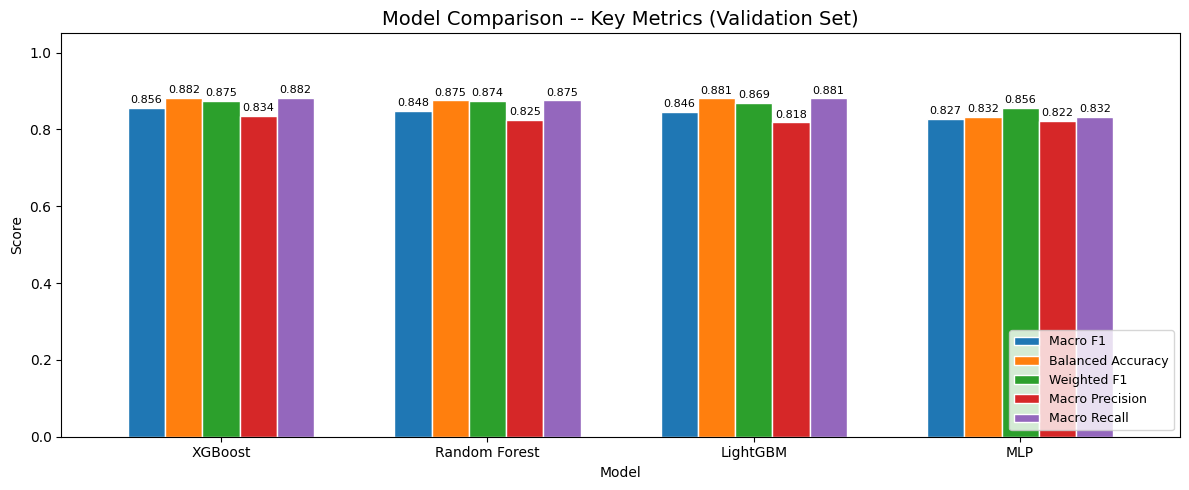

In [61]:
# grouped bar chart of key metrics
plotter.plot_comparison_bars(
    summary_df,
    metrics=["Macro F1", "Balanced Accuracy", "Weighted F1", "Macro Precision", "Macro Recall"],
    title="Model Comparison -- Key Metrics (Validation Set)",
)

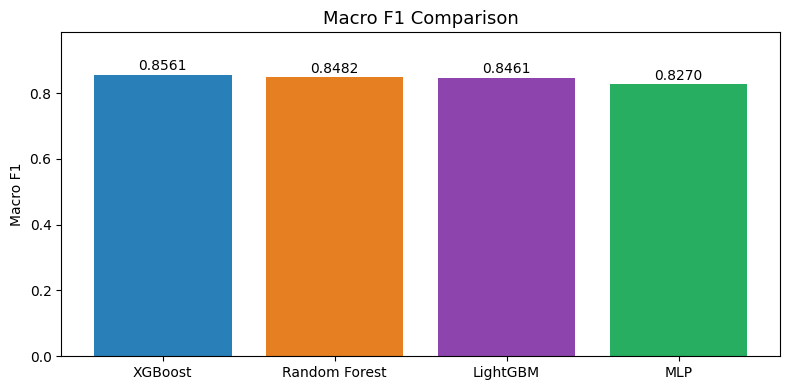

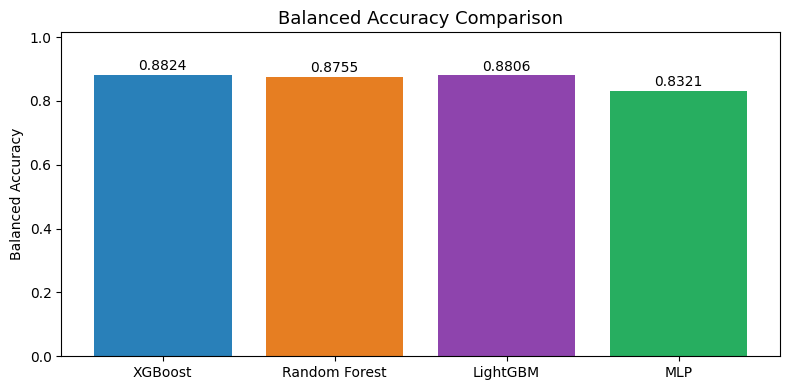

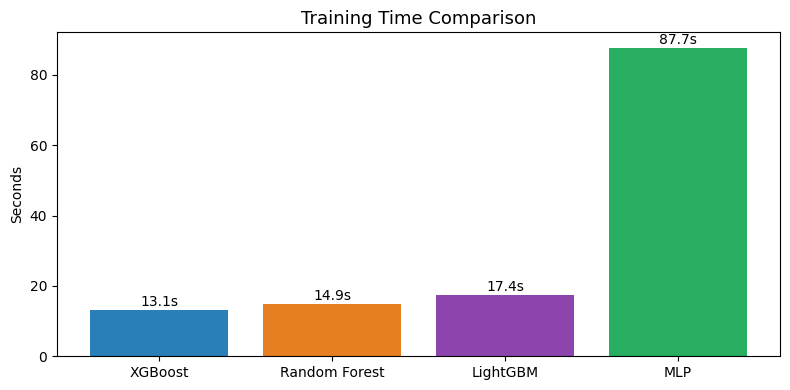

In [62]:
# individual metric comparisons and training time efficiency
plotter.plot_metric_comparison(summary_df, "Macro F1", "Macro F1 Comparison")
plotter.plot_metric_comparison(summary_df, "Balanced Accuracy", "Balanced Accuracy Comparison")
plotter.plot_training_time(summary_df)

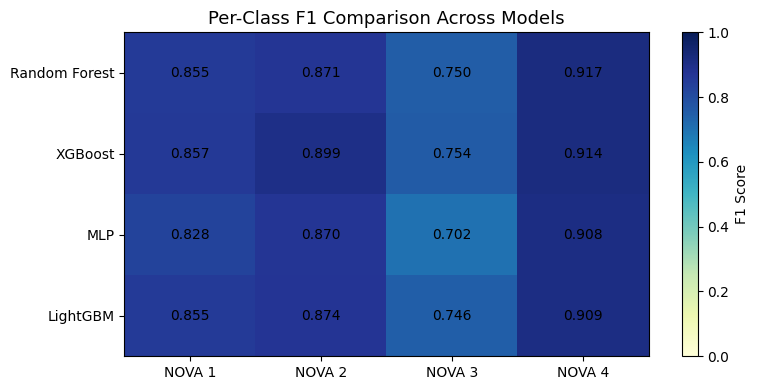

In [63]:
# heatmap of per-class F1 across all models — reveals which classes each model struggles with
plotter.plot_per_class_f1_heatmap(all_results, NOVA_LABELS)

### Interpretation
- Overall, the tree-based ensemble models outperformed the MLP, confirming that this structured tabular nutrition dataset is better suited to boosting and bagging approaches than a neural network.
- XGBoost emerged as the strongest overall model because it achieved the best Macro F1 (0.8561) and Balanced Accuracy (0.8824), which are the most important metrics for this imbalanced multiclass problem.
- Random Forest showed slightly higher raw accuracy (0.8729) than XGBoost, but its lower Macro F1 indicates that XGBoost provided better class-balanced performance across all NOVA groups.
- LightGBM was highly competitive and performed close to XGBoost, especially in Balanced Accuracy, but it remained slightly behind in Macro F1 and overall class discrimination.
- MLP delivered the weakest overall performance and required by far the longest training time (87.68 seconds), suggesting that deep learning was less efficient and less effective than ensemble tree methods for this project.
- Across all four models, NOVA 3 was consistently the most difficult class, while NOVA 4 was the easiest, indicating that moderate-processing foods have greater overlap with other categories, especially ultra-processed foods.
- From an efficiency perspective, XGBoost provided the best tradeoff between predictive performance and training time, making it the most suitable model to carry forward for final hyperparameter tuning.

---
## Final Model Selection

The best model is selected using the following criteria hierarchy:
1. **Primary**: Macro F1 (equally weights all classes, critical under imbalance)
2. **Secondary**: Balanced Accuracy
3. **Tertiary**: Minority class F1 performance, Log Loss, training efficiency

In [64]:
# select the best model — summary_df is already sorted by Macro F1 (descending)
best_row = summary_df.iloc[0]
best_model_name = best_row["Model"]
best_result = all_results[best_model_name]

# print selection summary
print(f"Selected model: {best_model_name}")
print(f"  Macro F1:          {best_row['Macro F1']:.4f}")
print(f"  Balanced Accuracy: {best_row['Balanced Accuracy']:.4f}")
print(f"  Weighted F1:       {best_row['Weighted F1']:.4f}")
if "Log Loss" in best_row:
    print(f"  Log Loss:          {best_row['Log Loss']:.4f}")
print(f"  Train Time:        {best_row['Train Time (s)']:.1f}s")

Selected model: XGBoost
  Macro F1:          0.8561
  Balanced Accuracy: 0.8824
  Weighted F1:       0.8747
  Log Loss:          0.3287
  Train Time:        13.1s


In [65]:
# minority class analysis — identify the weakest class for targeted tuning
print("Per-class F1 for selected model:")
display(best_result.per_class)

# find the class with the lowest F1 score (most room for improvement)
min_f1_class = best_result.per_class.loc[best_result.per_class["F1"].idxmin()]
print(f"\nWeakest class: {min_f1_class['Class']} (F1={min_f1_class['F1']:.4f})")
print("This class should receive focused attention during hyperparameter tuning.")

Per-class F1 for selected model:


,Class,Precision,Recall,F1,Support
0,NOVA 1,0.801262,0.920945,0.856945,5376.0
1,NOVA 2,0.878190,0.920925,0.899050,1644.0
2,NOVA 3,0.706942,0.807585,0.753920,8991.0
3,NOVA 4,0.951592,0.880049,0.914423,28770.0



Weakest class: NOVA 3 (F1=0.7539)
This class should receive focused attention during hyperparameter tuning.


### Selection Rationale

The model ranked first by Macro F1 is selected as the best candidate for the next stage. Macro F1 is the primary metric because it equally penalizes poor performance on any class, which is essential given the severe NOVA 4 dominance in the dataset. Balanced Accuracy serves as a secondary check to confirm that the model does not achieve high F1 by trivially predicting the majority class.

The selected model should advance to detailed hyperparameter tuning in the next notebook, with particular attention to improving performance on the weakest class identified above.

---
## Export Results

In [66]:
# create output directory if it doesn't exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# save comparison summary as CSV for easy reference and downstream analysis
summary_path = RESULTS_DIR / "model_comparison_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}")

# save selected model metadata as JSON for the hyperparameter tuning notebook
selection_meta = {
    "selected_model": best_model_name,
    "primary_metric": PRIMARY_METRIC,
    "primary_metric_value": round(float(best_row[PRIMARY_METRIC]), 4),
    "balanced_accuracy": round(float(best_row["Balanced Accuracy"]), 4),
    "weighted_f1": round(float(best_row["Weighted F1"]), 4),
    "all_models": list(all_results.keys()),
    "feature_count": len(feature_names),
    "n_classes": N_CLASSES,
}
meta_path = RESULTS_DIR / "selected_model_meta.json"
with open(meta_path, "w") as f:
    json.dump(selection_meta, f, indent=2)
print(f"Saved: {meta_path}")

# save per-class metrics for all models (useful for detailed analysis and reporting)
per_class_path = RESULTS_DIR / "per_class_metrics.csv"
per_class_all = []
for name, res in all_results.items():
    if res.per_class is not None:
        df_pc = res.per_class.copy()
        df_pc.insert(0, "Model", name)
        per_class_all.append(df_pc)
if per_class_all:
    pd.concat(per_class_all, ignore_index=True).to_csv(per_class_path, index=False)
    print(f"Saved: {per_class_path}")

Saved: models\model_comparison_summary.csv
Saved: models\selected_model_meta.json
Saved: models\per_class_metrics.csv


# Summary

XGBoost was selected as the final model because it best aligns with the project objective of predicting food processing tiers accurately across all NOVA classes. Since this is an imbalanced multiclass classification problem, the model was chosen based on class-balanced performance rather than accuracy alone, and XGBoost achieved the strongest overall results with the highest Macro F1 and Balanced Accuracy among the evaluated models.

It is also the most suitable technical choice for this project because the dataset is structured and tabular, with nutritional, additive, and engineered features that are well handled by gradient-boosted trees. In addition to strong predictive performance, XGBoost provides useful explainability through feature importance and SHAP-based interpretation, making the results easier to justify for both the report and the intended food quality assessment use case. Although some class-level bias remains, especially for NOVA 3, the model offers the best overall balance of performance, interpretability, and practical value.